In [1]:
# ── Aggressive VRAM cleanup before training ───────────────────────────────────
import gc
import torch

gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

if torch.cuda.is_available():
    print(f'VRAM free  : {torch.cuda.mem_get_info()[0] / 1e9:.2f} GB')
    print(f'VRAM total : {torch.cuda.mem_get_info()[1] / 1e9:.2f} GB')

VRAM free  : 5.96 GB
VRAM total : 6.09 GB


# MultiWOZ 2.2 Text Modality Notebook
## Week 3 and Week 4 — Fixed & GPU-Accelerated (v3)
### Data Preparation, Exploratory Analysis, and BERT-based Service Classification

**Key fixes in v3 (Tier 1 accuracy enhancements):**
- **CONTEXT WINDOW:** `USER_CONTEXT_WINDOW = 4` (was 2) — more user history = cleaner domain signal
- **MAX_LEN = 192** — prevents truncation of multi-turn concatenated inputs
- **INTENT PREFIX:** `active_intent` prepended to `model_input` — strong domain discriminator
- **LABEL SMOOTHING:** ε=0.1 in `WeightedTrainer` — reduces overfitting on short text
- **COSINE LR SCHEDULER** — better generalisation than linear decay
- **LR = 2e-5** — slightly lower, more stable convergence at this dataset scale
- **OOM FIX:** Zombie kernel detection + gradient checkpointing + 8-bit AdamW via TrainingArguments

**All v2 fixes retained:**
- `model_input` uses prior USER turns only (root cause of 0.78 fixed in v2)
- LR raised to 3e-5 in v2 (now tuned to 2e-5 in v3)
- 5 epochs with early stopping (patience=3)
- Turn-level labels, class weights, fp16, warmup, MIN_CLASS_COUNT

## 1. Research Motivation

- Task-oriented dialogue systems depend on precise text understanding.
- MultiWOZ 2.2 is a suitable benchmark for dialogue-based task understanding.
- For the text track, the key question is how well a model can identify task signals from user turns.
- This notebook frames the text task as supervised turn-level service classification.
- Labels are derived from the turn-level `active_services` field, which accurately reflects which service domain is active at each dialogue turn.
- The final pipeline is structured to support later multimodal extension.

In [2]:
!pip install "accelerate>=0.26.0"

In [3]:
import os
os.environ['TRANSFORMERS_NO_TF'] = '1'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['KERAS_BACKEND'] = 'torch'
# Must be set before ANY transformers import

In [4]:
os.environ["USE_TF"] = "0"

# ── Core imports ──────────────────────────────────────────────────────────────
import os
import re
import json
import math
import random
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud
import bitsandbytes as bnb

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style('whitegrid')

print('All core imports loaded.')

All core imports loaded.


## 2. Configuration

**v3 Tier 1 changes:**
- `USER_CONTEXT_WINDOW = 4` — more prior user turns for richer context
- `MAX_LEN = 192` — avoids truncating longer multi-turn inputs
- `LEARNING_RATE = 2e-5` — slightly lower, more stable for this dataset size
- Intent prefix is added in the parser (`USE_INTENT_PREFIX = True`)

In [5]:
# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_ROOT        = Path('/home/ahmed/workspace/IR_text_paper/MultiWOZ_2.2')
TRAIN_DIR        = DATA_ROOT / 'train'
DEV_DIR          = DATA_ROOT / 'dev'
TEST_DIR         = DATA_ROOT / 'test'
SCHEMA_PATH      = DATA_ROOT / 'schema.json'
DIALOG_ACTS_PATH = DATA_ROOT / 'dialog_acts.json'

# ── Output directory ──────────────────────────────────────────────────────────
OUTPUT_DIR = Path('./working')
FIG_DIR    = OUTPUT_DIR / 'figures'
MODEL_DIR  = OUTPUT_DIR / 'models'
TABLE_DIR  = OUTPUT_DIR / 'tables'

for p in [OUTPUT_DIR, FIG_DIR, MODEL_DIR, TABLE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# ── Model ─────────────────────────────────────────────────────────────────────
MODEL_FAMILY       = 'BERT'
MODEL_NAME_OR_PATH = 'bert-base-uncased'

# ── Training hyperparameters ──────────────────────────────────────────────────
MAX_LEN        = 192      # v3: raised from 128 — avoids truncating multi-turn inputs
BATCH_SIZE     = 16       # OOM-safe default; effective batch = 32 via grad accumulation
EPOCHS         = 5       # v3: slightly more headroom; early stopping handles overfitting
LEARNING_RATE  = 2e-5     # v3: 2e-5 more stable than 3e-5 at this dataset scale
WARMUP_RATIO   = 0.1
WEIGHT_DECAY   = 0.01
FP16           = True
USER_CONTEXT_WINDOW     = 4   # v3: raised from 2 — more user history = cleaner domain signal
EARLY_STOPPING_PATIENCE = 3
USE_INTENT_PREFIX       = True  # v3: prepend active_intent to model_input

# ── Label filtering ───────────────────────────────────────────────────────────
TARGET_COL      = 'turn_service'
USE_USER_TURNS  = True
MIN_CLASS_COUNT = 500

print('Configuration loaded (v3).')
print(f'Output directory: {OUTPUT_DIR.resolve()}')

Configuration loaded (v3).
Output directory: /home/ahmed/workspace/IR_text_paper/working


## 3. CUDA Verification

- Verifies that PyTorch detects the RTX 3060 before any training begins.
- If CUDA is not found, check that the correct CUDA-enabled PyTorch is installed (`pip install torch --index-url https://download.pytorch.org/whl/cu121`).

In [6]:
import torch

print('PyTorch version :', torch.__version__)
print('CUDA available  :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU name        :', torch.cuda.get_device_name(0))
    print('VRAM (GB)       :', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2))
    DEVICE = 'cuda'
else:
    print('WARNING: CUDA not found — training will run on CPU (slow).')
    DEVICE = 'cpu'
    FP16 = False

PyTorch version : 2.6.0+cu124
CUDA available  : True
GPU name        : NVIDIA GeForce RTX 3060 Laptop GPU
VRAM (GB)       : 6.09


## 4. Local Data Validation

In [8]:
expected_paths = {
    'DATA_ROOT'       : DATA_ROOT,
    'TRAIN_DIR'       : TRAIN_DIR,
    'DEV_DIR'         : DEV_DIR,
    'TEST_DIR'        : TEST_DIR,
    'SCHEMA_PATH'     : SCHEMA_PATH,
    'DIALOG_ACTS_PATH': DIALOG_ACTS_PATH,
}

rows = []
for name, path in expected_paths.items():
    rows.append({'item': name, 'path': str(path),
                 'exists': path.exists(),
                 'type': 'dir' if path.is_dir() else 'file'})

val_df = pd.DataFrame(rows)
assert val_df['exists'].all(), 'Some paths are missing — update DATA_ROOT in configuration.'
print('All dataset paths verified.')

All dataset paths verified.


## 5. Utility Functions for MultiWOZ 2.2 Parsing

**v3 changes:**
- `USE_INTENT_PREFIX = True` prepends `[intent: <active_intent>]` to `model_input`.
  The active intent (e.g. `FindRestaurant`, `BookTrain`) is a near-perfect domain discriminator
  and provides BERT with an unambiguous classification signal before reading the utterance.
- `USER_CONTEXT_WINDOW = 4` (was 2) — more prior user turns give richer context without
  introducing cross-domain noise (system turns are still excluded, as per v2 fix).

In [9]:
def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

def iter_dialogue_objects(obj):
    if isinstance(obj, list):
        for item in obj:
            if isinstance(item, dict):
                yield item
    elif isinstance(obj, dict):
        if 'dialogue_id' in obj or 'turns' in obj:
            yield obj
        else:
            for value in obj.values():
                if isinstance(value, dict):
                    yield value
                elif isinstance(value, list):
                    for item in value:
                        if isinstance(item, dict):
                            yield item

def get_json_files(split_dir):
    return sorted(split_dir.rglob('*.json'))

def normalize_text(text):
    text = '' if text is None else str(text)
    text = text.lower()
    text = re.sub(r'[\x00-\x1f\x7f]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def safe_first(x, default=None):
    return x[0] if isinstance(x, list) and len(x) > 0 else default


def extract_turn_records(dialogue, split_name, user_context_window=4, use_intent_prefix=True):
    """
    Extract turn-level records with turn-accurate service labels.

    v3 changes:
    - use_intent_prefix: prepend '[intent: <active_intent>]' to model_input.
      Active intent is the strongest single domain signal in MultiWOZ 2.2.
    - user_context_window=4: more prior user turns for richer context.

    v2 fix retained:
    - model_input uses only prior USER utterances as context (no system turns).
      System turns were injecting cross-domain vocabulary causing 0.78 accuracy.
    """
    dialogue_id   = dialogue.get('dialogue_id') or dialogue.get('dialog_id') or dialogue.get('id')
    dialogue_svcs = dialogue.get('services', [])
    turns         = dialogue.get('turns', [])
    rows          = []
    user_history  = []   # user utterances only

    for turn_idx, turn in enumerate(turns):
        raw_utt   = turn.get('utterance', '')
        utterance = normalize_text(raw_utt)
        speaker   = str(turn.get('speaker', turn.get('role', 'unknown'))).upper()
        frames    = turn.get('frames', [])

        active_services = []
        active_intents  = []
        requested_slots = []
        slot_keys       = []

        if isinstance(frames, list):
            for fr in frames:
                if not isinstance(fr, dict):
                    continue
                svc = fr.get('service')
                if svc:
                    active_services.append(svc.lower())
                state = fr.get('state', {})
                if isinstance(state, dict):
                    intent = state.get('active_intent')
                    if intent and intent != 'NONE':
                        active_intents.append(intent)
                    req = state.get('requested_slots', [])
                    if isinstance(req, list):
                        requested_slots.extend(req)
                    sv = state.get('slot_values', {})
                    if isinstance(sv, dict):
                        slot_keys.extend(sv.keys())

        turn_service = safe_first(active_services,
                                  default=safe_first(dialogue_svcs, default='unknown'))
        if turn_service:
            turn_service = turn_service.lower()

        active_intent = safe_first(active_intents, default='NONE')

        if speaker == 'USER':
            # Build context from prior user turns only
            if user_history and user_context_window > 0:
                ctx = ' [SEP] '.join(user_history[-user_context_window:])
                base_input = ctx + ' [SEP] ' + utterance
            else:
                base_input = utterance

            # v3: prepend intent prefix for strong domain signal
            if use_intent_prefix and active_intent != 'NONE':
                model_input = f'[intent: {active_intent.lower()}] {base_input}'
            else:
                model_input = base_input

            rows.append({
                'split'              : split_name,
                'dialogue_id'        : dialogue_id,
                'turn_id'            : turn.get('turn_id', turn_idx),
                'turn_index'         : turn_idx,
                'speaker'            : speaker,
                'utterance'          : utterance,
                'model_input'        : model_input,
                'utterance_length_words': len(utterance.split()),
                'dialogue_services'  : dialogue_svcs,
                'active_services'    : active_services,
                'turn_service'       : turn_service,
                'active_intent'      : active_intent,
                'requested_slots'    : sorted(set(requested_slots)),
                'slot_keys'          : sorted(set(slot_keys)),
                'num_active_services': len(set(active_services)),
                'num_requested_slots': len(set(requested_slots)),
                'num_slot_keys'      : len(set(slot_keys)),
            })

            user_history.append(utterance)

    return rows


def load_split_records(split_dir, split_name, user_context_window=4, use_intent_prefix=True):
    all_rows = []
    json_files = get_json_files(split_dir)
    for jf in json_files:
        try:
            obj = load_json(jf)
            for dialogue in iter_dialogue_objects(obj):
                if isinstance(dialogue, dict) and 'turns' in dialogue:
                    all_rows.extend(extract_turn_records(
                        dialogue, split_name,
                        user_context_window=user_context_window,
                        use_intent_prefix=use_intent_prefix
                    ))
        except Exception as e:
            print(f'Skipping {jf}: {e}')
    return pd.DataFrame(all_rows)

print('Parser functions defined (v3: intent prefix + wider context window).')

Parser functions defined (v3: intent prefix + wider context window).


## 6. Load Train, Validation, and Test Splits

In [10]:
print('Loading MultiWOZ 2.2 from local disk...')
train_df = load_split_records(TRAIN_DIR, 'train',
                               user_context_window=USER_CONTEXT_WINDOW,
                               use_intent_prefix=USE_INTENT_PREFIX)
dev_df   = load_split_records(DEV_DIR,   'dev',
                               user_context_window=USER_CONTEXT_WINDOW,
                               use_intent_prefix=USE_INTENT_PREFIX)
test_df  = load_split_records(TEST_DIR,  'test',
                               user_context_window=USER_CONTEXT_WINDOW,
                               use_intent_prefix=USE_INTENT_PREFIX)

full_df = pd.concat([train_df, dev_df, test_df], ignore_index=True)

print(f'Train shape : {train_df.shape}')
print(f'Dev shape   : {dev_df.shape}')
print(f'Test shape  : {test_df.shape}')
print(f'Full shape  : {full_df.shape}')

Loading MultiWOZ 2.2 from local disk...
Train shape : (56776, 17)
Dev shape   : (7374, 17)
Test shape  : (7372, 17)
Full shape  : (71522, 17)


## 7. Initial Data Inspection

In [11]:
display_cols = ['split', 'dialogue_id', 'turn_index', 'utterance',
                'turn_service', 'active_intent', 'model_input']
full_df[display_cols].head(12)

,split,dialogue_id,turn_index,utterance,turn_service,active_intent,model_input
0,train,PMUL4398.json,0,i need a place to dine in the center thats exp...,restaurant,find_restaurant,[intent: find_restaurant] i need a place to di...
1,train,PMUL4398.json,2,"any sort of food would be fine, as long as it ...",restaurant,find_restaurant,[intent: find_restaurant] i need a place to di...
2,train,PMUL4398.json,4,"sounds good, could i get that phone number? al...",restaurant,find_restaurant,[intent: find_restaurant] i need a place to di...
3,train,PMUL4398.json,6,yes. can you book it for me?,restaurant,find_hotel,[intent: find_hotel] i need a place to dine in...
4,train,PMUL4398.json,8,i want to book it for 2 people and 2 nights st...,restaurant,book_hotel,[intent: book_hotel] i need a place to dine in...
5,train,PMUL4398.json,10,"that is all i need to know. thanks, good bye.",restaurant,NONE,"any sort of food would be fine, as long as it ..."
6,train,SNG1013.json,0,"guten tag, i am staying overnight in cambridge...",hotel,find_hotel,"[intent: find_hotel] guten tag, i am staying o..."
7,train,SNG1013.json,2,"no, but i'd really like to be on the south end...",hotel,find_hotel,"[intent: find_hotel] guten tag, i am staying o..."
8,train,SNG1013.json,4,no i don't care about the price. which one do ...,hotel,find_hotel,"[intent: find_hotel] guten tag, i am staying o..."
9,train,SNG1013.json,6,"yes, book it for 4 people and 4 nights startin...",hotel,book_hotel,"[intent: book_hotel] guten tag, i am staying o..."


## 8. Data Quality Audit

In [12]:
quality_summary = pd.DataFrame({
    'missing_count': full_df.isna().sum(),
    'missing_ratio': full_df.isna().mean().round(4)
}).sort_values('missing_count', ascending=False)
quality_summary

,missing_count,missing_ratio
split,0,0.0
dialogue_id,0,0.0
turn_id,0,0.0
turn_index,0,0.0
speaker,0,0.0
utterance,0,0.0
model_input,0,0.0
utterance_length_words,0,0.0
dialogue_services,0,0.0
active_services,0,0.0


## 9. Core Descriptive Statistics

In [13]:
summary_rows = []
for split_name, df_ in [('train', train_df), ('dev', dev_df), ('test', test_df), ('full', full_df)]:
    summary_rows.append({
        'split'                   : split_name,
        'num_rows'                : len(df_),
        'num_dialogues'           : df_['dialogue_id'].nunique(),
        'avg_turn_length_words'   : round(df_['utterance_length_words'].mean(), 2),
        'median_turn_length_words': round(df_['utterance_length_words'].median(), 2),
        'num_services'            : df_['turn_service'].nunique(),
        'num_intents'             : df_['active_intent'].nunique(),
    })

dataset_summary_df = pd.DataFrame(summary_rows)
dataset_summary_df.to_csv(TABLE_DIR / 'dataset_summary.csv', index=False)
dataset_summary_df

,split,num_rows,num_dialogues,avg_turn_length_words,median_turn_length_words,num_services,num_intents
0,train,56776,8437,11.42,10.0,7,12
1,dev,7374,1000,11.69,11.0,6,10
2,test,7372,1000,11.74,11.0,5,10
3,full,71522,10437,11.48,11.0,7,12


## 10. Exploratory Data Analysis — Publication Figures

Five publication-quality figures are generated and saved to `working/figures/`.

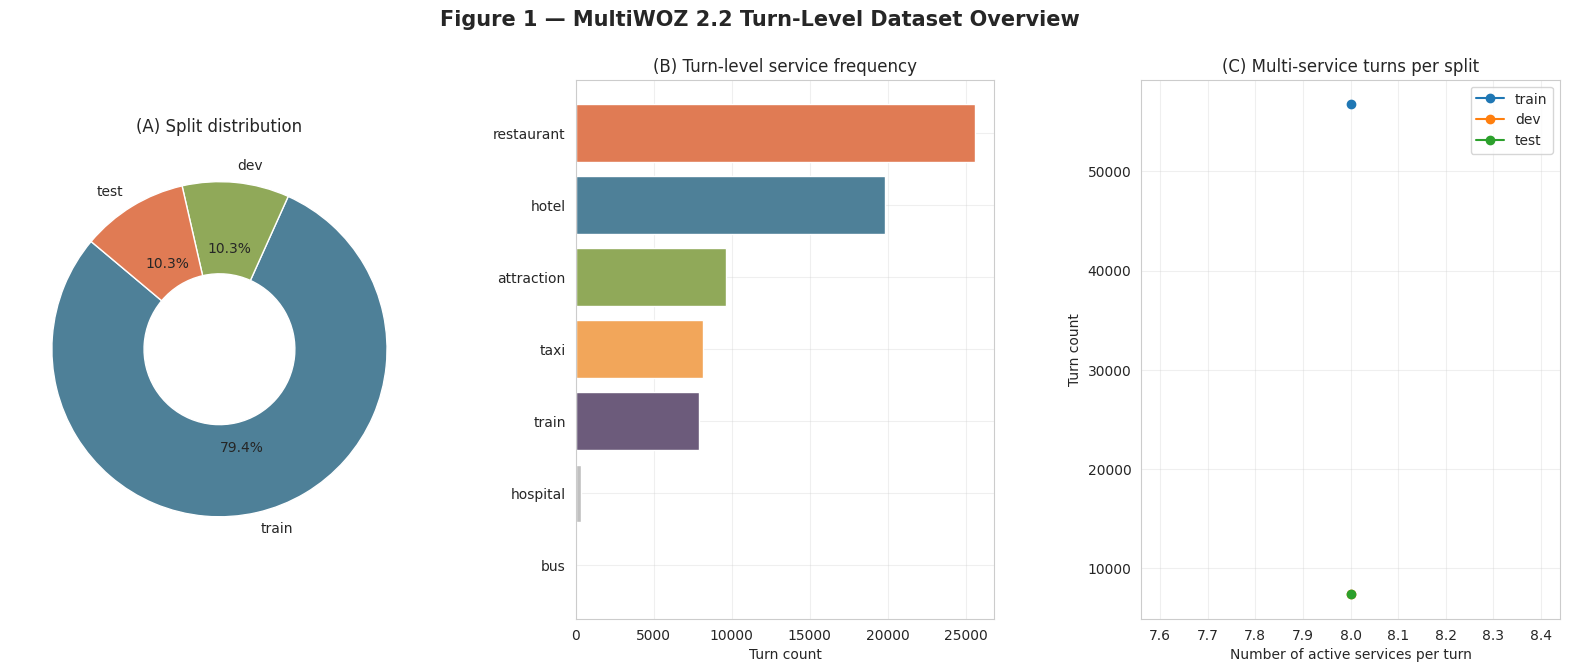

Figure 1 saved.


In [14]:
# ── Figure 1: Dataset Overview ────────────────────────────────────────────────
service_counts = full_df['turn_service'].value_counts().sort_values(ascending=False)
split_counts   = full_df['split'].value_counts().reindex(['train', 'dev', 'test'])

PALETTE = {
    'restaurant': '#E07B54', 'hotel': '#4E8098', 'attraction': '#90A959',
    'train': '#6C5B7B', 'taxi': '#F2A65A', 'hospital': '#C0C0C0',
    'bus': '#A0A0A0', 'unknown': '#D0D0D0'
}

fig = plt.figure(figsize=(20, 7))
fig.suptitle('Figure 1 — MultiWOZ 2.2 Turn-Level Dataset Overview',
             fontsize=15, fontweight='bold')
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

ax1 = fig.add_subplot(gs[0])
wedge_cols = ['#4E8098', '#90A959', '#E07B54']
ax1.pie(split_counts, labels=split_counts.index, autopct='%1.1f%%',
        colors=wedge_cols, wedgeprops={'width': 0.55}, startangle=140)
ax1.set_title('(A) Split distribution', fontsize=12)

ax2 = fig.add_subplot(gs[1])
top_svcs = service_counts.head(8)
bars = ax2.barh(top_svcs.index[::-1], top_svcs.values[::-1],
                color=[PALETTE.get(s, '#888') for s in top_svcs.index[::-1]])
ax2.set_xlabel('Turn count')
ax2.set_title('(B) Turn-level service frequency', fontsize=12)

ax3 = fig.add_subplot(gs[2])
for split_name, df_ in [('train', train_df), ('dev', dev_df), ('test', test_df)]:
    cnts = df_['num_active_services'].value_counts().sort_index()
    ax3.plot(cnts.index, cnts.values, marker='o', label=split_name)
ax3.set_xlabel('Number of active services per turn')
ax3.set_ylabel('Turn count')
ax3.set_title('(C) Multi-service turns per split', fontsize=12)
ax3.legend()

plt.savefig(FIG_DIR / 'fig1_dataset_overview.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

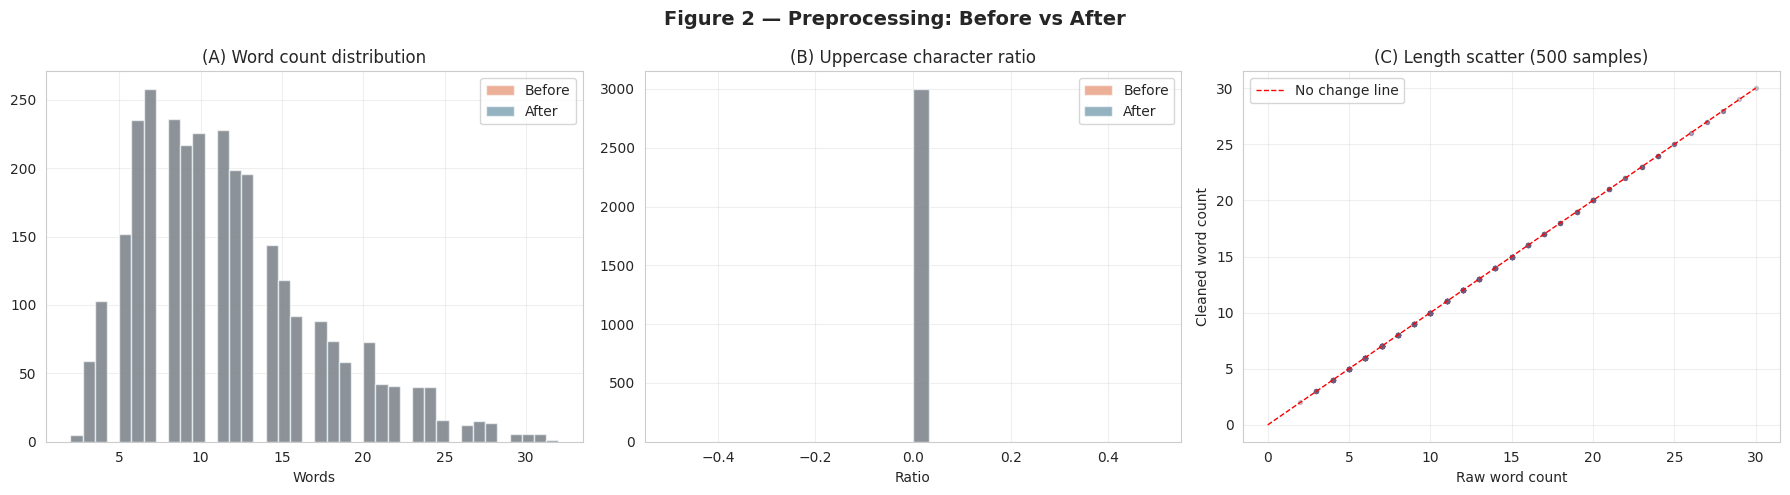

Figure 2 saved.


In [15]:
# ── Figure 2: Preprocessing Before vs After ───────────────────────────────────
raw_samples, cln_samples = [], []
raw_upper, cln_upper = [], []
n_collect = 3000

for _, row in train_df.head(n_collect).iterrows():
    raw = str(row['utterance'])
    cln = normalize_text(raw)
    raw_samples.append(len(raw.split()))
    cln_samples.append(len(cln.split()))
    raw_upper.append(sum(c.isupper() for c in raw) / max(len(raw), 1))
    cln_upper.append(sum(c.isupper() for c in cln) / max(len(cln), 1))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Figure 2 — Preprocessing: Before vs After', fontsize=14, fontweight='bold')

axes[0].hist(raw_samples, bins=40, alpha=0.6, label='Before', color='#E07B54')
axes[0].hist(cln_samples, bins=40, alpha=0.6, label='After',  color='#4E8098')
axes[0].set_title('(A) Word count distribution')
axes[0].set_xlabel('Words')
axes[0].legend()

axes[1].hist(raw_upper, bins=30, alpha=0.6, label='Before', color='#E07B54')
axes[1].hist(cln_upper, bins=30, alpha=0.6, label='After',  color='#4E8098')
axes[1].set_title('(B) Uppercase character ratio')
axes[1].set_xlabel('Ratio')
axes[1].legend()

axes[2].scatter(raw_samples[:500], cln_samples[:500], alpha=0.3, s=8, color='#6C5B7B')
lim = max(max(raw_samples[:500]), max(cln_samples[:500]))
axes[2].plot([0, lim], [0, lim], 'r--', lw=1, label='No change line')
axes[2].set_title('(C) Length scatter (500 samples)')
axes[2].set_xlabel('Raw word count')
axes[2].set_ylabel('Cleaned word count')
axes[2].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_preprocessing.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

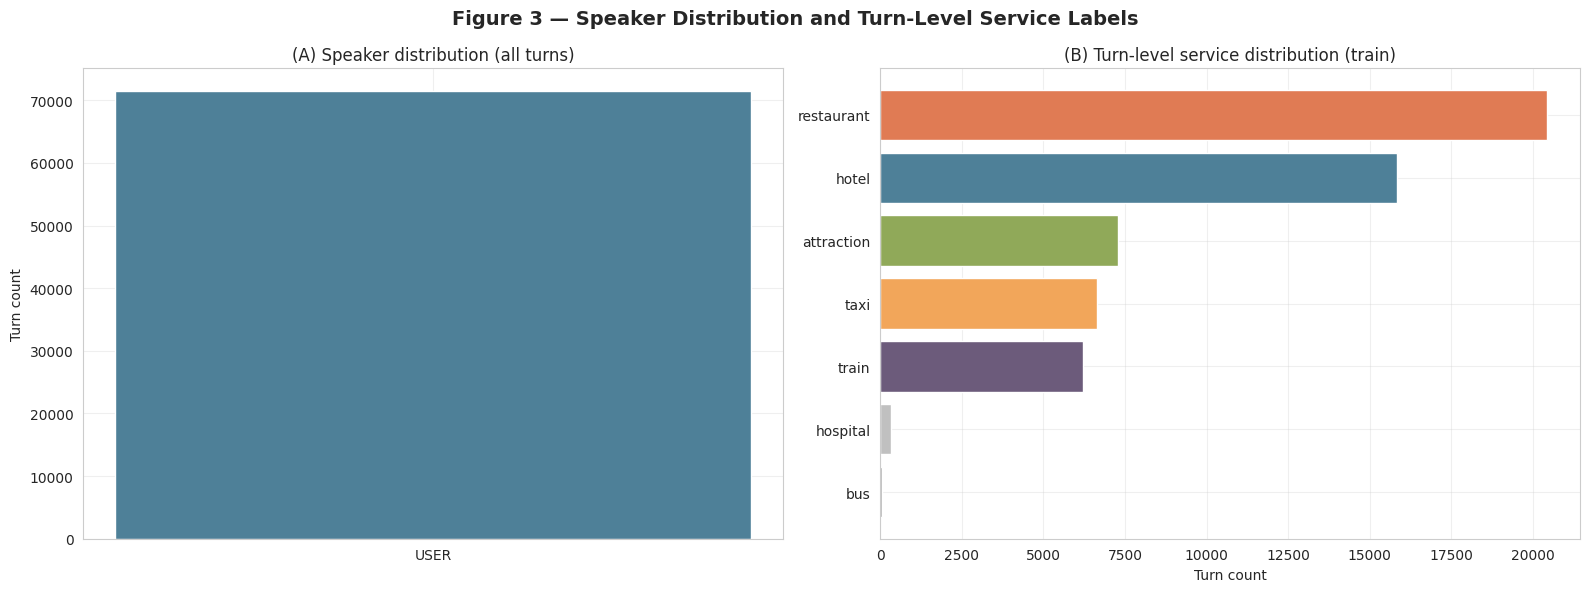

Figure 3 saved.


In [16]:
# ── Figure 3: Speaker & Service Distribution ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Figure 3 — Speaker Distribution and Turn-Level Service Labels',
             fontsize=14, fontweight='bold')

spk = full_df['speaker'].value_counts()
axes[0].bar(spk.index, spk.values, color=['#4E8098', '#E07B54'])
axes[0].set_title('(A) Speaker distribution (all turns)')
axes[0].set_ylabel('Turn count')

svc_dist = train_df['turn_service'].value_counts().sort_values(ascending=True)
colors = [PALETTE.get(s, '#888') for s in svc_dist.index]
axes[1].barh(svc_dist.index, svc_dist.values, color=colors)
axes[1].set_title('(B) Turn-level service distribution (train)')
axes[1].set_xlabel('Turn count')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig3_label_distribution.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

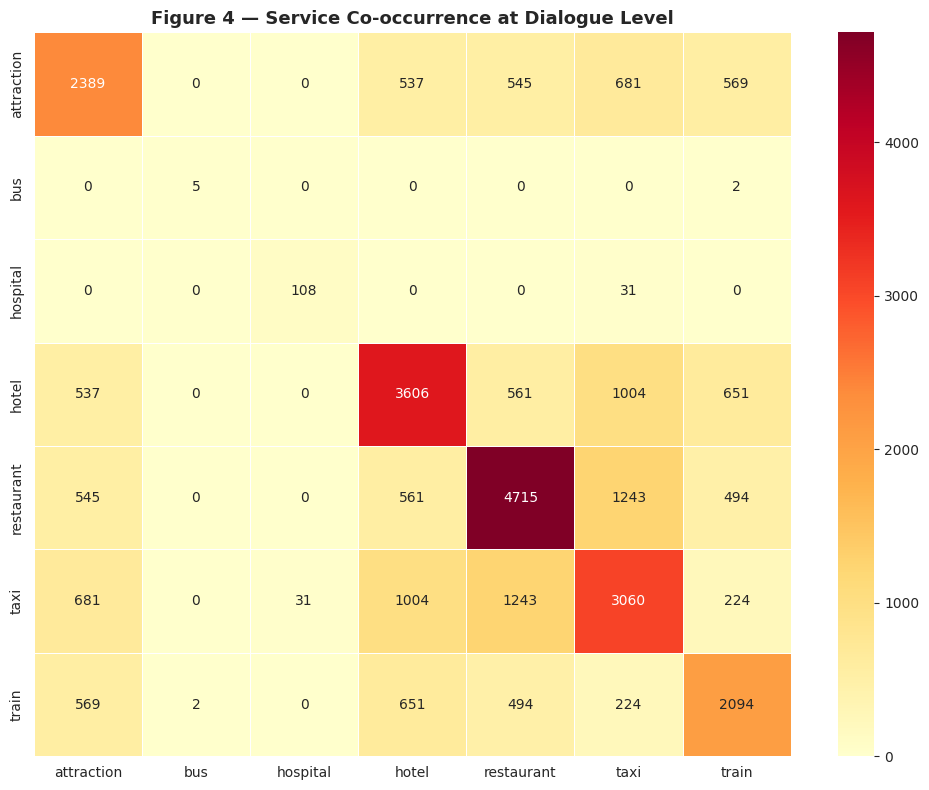

Figure 4 saved.


In [17]:
# ── Figure 4: Service Co-occurrence Heatmap ───────────────────────────────────
all_svcs = sorted(full_df['turn_service'].dropna().unique())
svc_idx  = {s: i for i, s in enumerate(all_svcs)}
co_mat   = np.zeros((len(all_svcs), len(all_svcs)), dtype=int)

dlg_map = (full_df.groupby('dialogue_id')['turn_service']
           .apply(lambda x: sorted(set(x.dropna())))
           .to_dict())

for svcs in dlg_map.values():
    for s1 in svcs:
        for s2 in svcs:
            if s1 in svc_idx and s2 in svc_idx:
                co_mat[svc_idx[s1], svc_idx[s2]] += 1

co_df = pd.DataFrame(co_mat, index=all_svcs, columns=all_svcs)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(co_df, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_title('Figure 4 — Service Co-occurrence at Dialogue Level',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig4_cooccurrence_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

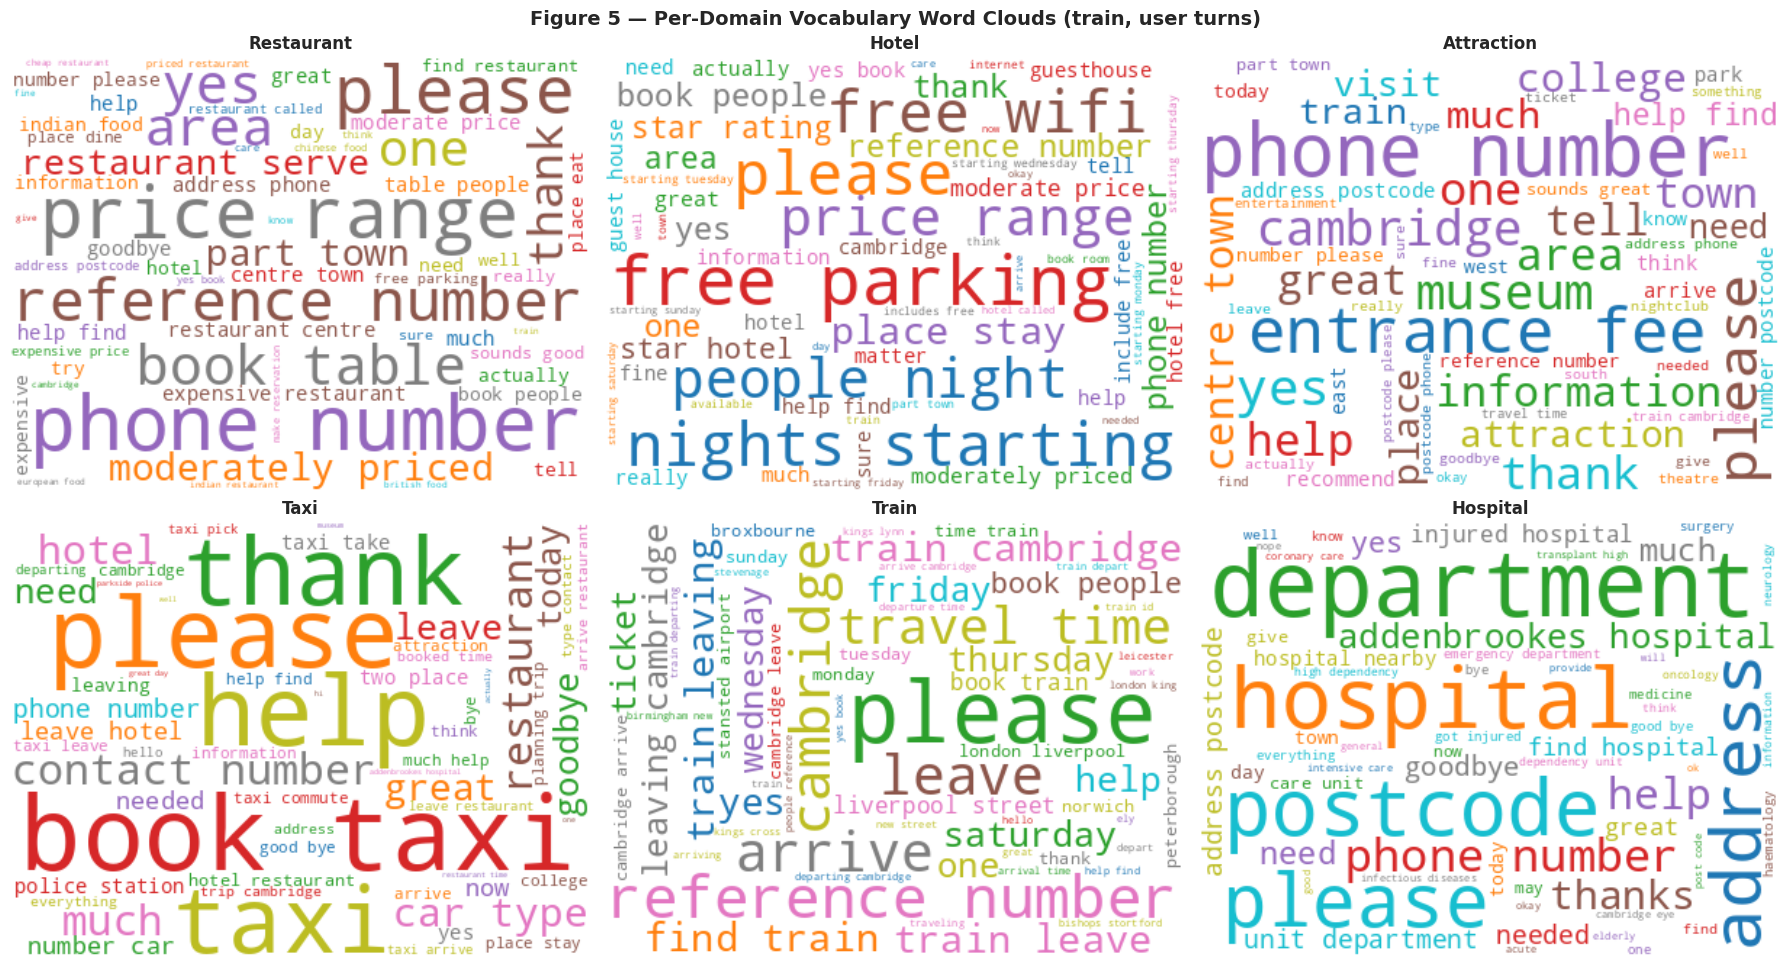

Figure 5 saved.


In [18]:
# ── Figure 5: Per-Domain Word Clouds ─────────────────────────────────────────
STOPWORDS = {
    'i','me','my','we','our','you','your','it','its','they','them',
    'is','are','was','were','be','been','have','has','had','do','does',
    'did','a','an','the','and','but','if','or','as','at','by','for',
    'with','of','to','from','in','on','would','could','should','will',
    'can','please','yes','no','okay','thank','thanks','just','also',
    'any','all','some','not','so','then','there','here','that','this',
    'what','which','who','want','need','looking','going','like','get','sep','intent'
}

domain_text = defaultdict(list)
for _, row in train_df.iterrows():
    svc = row.get('turn_service', '')
    utt = row.get('utterance', '')
    if svc and utt:
        tokens = [w for w in utt.split() if w not in STOPWORDS and len(w) > 2]
        domain_text[svc].append(' '.join(tokens))

top_domains = [s for s, _ in service_counts.head(6).items()]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Figure 5 — Per-Domain Vocabulary Word Clouds (train, user turns)',
             fontsize=14, fontweight='bold')

for ax, domain in zip(axes.flatten(), top_domains):
    corpus = ' '.join(domain_text.get(domain, ['']))
    if corpus.strip():
        wc = WordCloud(width=400, height=300, background_color='white',
                       colormap='tab10', max_words=60).generate(corpus)
        ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(domain.capitalize(), fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig5_wordclouds.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figure 5 saved.')

## 11. Preprocessing — Label Filtering and Modeling Table

In [19]:
work_df = full_df.copy()

work_df['model_input'] = work_df['model_input'].fillna('').map(normalize_text)
work_df = work_df[work_df['model_input'].str.len() > 0].copy()

work_df[TARGET_COL] = work_df[TARGET_COL].fillna('unknown').astype(str).str.lower()

print('Raw turn-level service counts (train):')
raw_train_counts = train_df[TARGET_COL].value_counts()
print(raw_train_counts.to_string())
print()

label_counts = work_df[work_df['split'] == 'train'][TARGET_COL].value_counts()
valid_labels = label_counts[label_counts >= MIN_CLASS_COUNT].index.tolist()

print(f'Labels kept (>= {MIN_CLASS_COUNT} train samples):')
for lbl in sorted(valid_labels):
    print(f'  {lbl:<20} {label_counts[lbl]:>6,}')
print(f'Labels dropped: {[l for l in label_counts.index if l not in valid_labels]}')

filtered_df = work_df[work_df[TARGET_COL].isin(valid_labels)].copy()

print(f'\nOriginal rows    : {len(full_df):,}')
print(f'After filtering  : {len(filtered_df):,}')
print(f'Number of labels : {filtered_df[TARGET_COL].nunique()}')

Raw turn-level service counts (train):
turn_service
restaurant    20420
hotel         15843
attraction     7284
taxi           6650
train          6204
hospital        335
bus              40

Labels kept (>= 500 train samples):
  attraction            7,284
  hotel                15,843
  restaurant           20,420
  taxi                  6,650
  train                 6,204
Labels dropped: ['hospital', 'bus']

Original rows    : 71,522
After filtering  : 71,140
Number of labels : 5


In [20]:
model_df = filtered_df[[
    'split', 'dialogue_id', 'turn_index', 'utterance',
    'model_input', TARGET_COL, 'active_intent', 'utterance_length_words'
]].copy().rename(columns={TARGET_COL: 'label'})

labels   = sorted(model_df['label'].unique())
label2id = {lbl: i for i, lbl in enumerate(labels)}
id2label = {i: lbl for lbl, i in label2id.items()}
model_df['label_id'] = model_df['label'].map(label2id)

label_map_df = pd.DataFrame({'label': labels, 'label_id': [label2id[l] for l in labels]})
label_map_df.to_csv(TABLE_DIR / f'label_mapping_{TARGET_COL}.csv', index=False)

print('Label encoding:')
print(label_map_df.to_string(index=False))
model_df.head(8)

Label encoding:
     label  label_id
attraction         0
     hotel         1
restaurant         2
      taxi         3
     train         4


,split,dialogue_id,turn_index,utterance,model_input,label,active_intent,utterance_length_words,label_id
0,train,PMUL4398.json,0,i need a place to dine in the center thats exp...,[intent: find_restaurant] i need a place to di...,restaurant,find_restaurant,11,2
1,train,PMUL4398.json,2,"any sort of food would be fine, as long as it ...",[intent: find_restaurant] i need a place to di...,restaurant,find_restaurant,24,2
2,train,PMUL4398.json,4,"sounds good, could i get that phone number? al...",[intent: find_restaurant] i need a place to di...,restaurant,find_restaurant,16,2
3,train,PMUL4398.json,6,yes. can you book it for me?,[intent: find_hotel] i need a place to dine in...,restaurant,find_hotel,7,2
4,train,PMUL4398.json,8,i want to book it for 2 people and 2 nights st...,[intent: book_hotel] i need a place to dine in...,restaurant,book_hotel,14,2
5,train,PMUL4398.json,10,"that is all i need to know. thanks, good bye.","any sort of food would be fine, as long as it ...",restaurant,NONE,10,2
6,train,SNG1013.json,0,"guten tag, i am staying overnight in cambridge...","[intent: find_hotel] guten tag, i am staying o...",hotel,find_hotel,20,1
7,train,SNG1013.json,2,"no, but i'd really like to be on the south end...","[intent: find_hotel] guten tag, i am staying o...",hotel,find_hotel,21,1


In [21]:
train_model_df = model_df[model_df['split'] == 'train'].copy()
dev_model_df   = model_df[model_df['split'] == 'dev'].copy()
test_model_df  = model_df[model_df['split'] == 'test'].copy()

print(f'Train : {len(train_model_df):,} rows')
print(f'Dev   : {len(dev_model_df):,} rows')
print(f'Test  : {len(test_model_df):,} rows')
print()
print('Train label distribution:')
print(train_model_df['label'].value_counts().to_string())

Train : 56,401 rows
Dev   : 7,367 rows
Test  : 7,372 rows

Train label distribution:
label
restaurant    20420
hotel         15843
attraction     7284
taxi           6650
train          6204


## 12. Class Weight Computation

In [22]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              classification_report, confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           Trainer, TrainingArguments)

train_label_ids = train_model_df['label_id'].values
class_weights_np = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(labels)),
    y=train_label_ids
)
class_weights_tensor = torch.tensor(class_weights_np, dtype=torch.float32)

print('Class weights (balanced):')
for lbl, w in zip(labels, class_weights_np):
    print(f'  {lbl:<20} {w:.4f}')

Class weights (balanced):
  attraction           1.5486
  hotel                0.7120
  restaurant           0.5524
  taxi                 1.6963
  train                1.8182


## 13. Tokenizer and Dataset Wrapper

In [23]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME_OR_PATH)

class MultiWOZDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len=192):
        self.df        = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        enc = self.tokenizer(
            row['model_input'],
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item['labels'] = torch.tensor(int(row['label_id']), dtype=torch.long)
        return item


train_dataset = MultiWOZDataset(train_model_df, tokenizer, max_len=MAX_LEN)
dev_dataset   = MultiWOZDataset(dev_model_df,   tokenizer, max_len=MAX_LEN)
test_dataset  = MultiWOZDataset(test_model_df,  tokenizer, max_len=MAX_LEN)

print(f'Train dataset : {len(train_dataset):,} samples')
print(f'Dev dataset   : {len(dev_dataset):,} samples')
print(f'Test dataset  : {len(test_dataset):,} samples')

Train dataset : 56,401 samples
Dev dataset   : 7,367 samples
Test dataset  : 7,372 samples


## 14. Evaluation Metrics

In [24]:
def compute_metrics(eval_pred):
    logits, labels_true = eval_pred
    preds = np.argmax(logits, axis=1)

    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        labels_true, preds, average='macro', zero_division=0)
    p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(
        labels_true, preds, average='weighted', zero_division=0)
    acc = accuracy_score(labels_true, preds)

    return {
        'accuracy'           : acc,
        'f1_macro'           : f1_macro,
        'f1_weighted'        : f1_weighted,
        'precision_macro'    : p_macro,
        'recall_macro'       : r_macro,
        'precision_weighted' : p_weighted,
        'recall_weighted'    : r_weighted,
    }

## 15. Custom Trainer with Weighted Cross-Entropy Loss + Label Smoothing

**v3:** Added `label_smoothing=0.1` to the loss function.
Label smoothing prevents overconfident predictions on short ambiguous utterances
and acts as a regularizer, typically adding 0.5–1.5% accuracy on classification tasks.

In [25]:
class WeightedTrainer(Trainer):
    """Trainer with class-weighted cross-entropy loss and label smoothing (v3)."""

    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits

        if self.class_weights is not None:
            weights = self.class_weights.to(logits.device)
            loss_fn = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.1)  # v3: label smoothing
        else:
            loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

print('WeightedTrainer defined (v3: label smoothing ε=0.1).')

WeightedTrainer defined (v3: label smoothing ε=0.1).


## 16. VRAM Cleanup Before Training

In [26]:
import gc
import subprocess

gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

if torch.cuda.is_available():
    free, total = torch.cuda.mem_get_info()
    print(f'VRAM free  : {free / 1e9:.2f} GB')
    print(f'VRAM total : {total / 1e9:.2f} GB')
    if free < 3e9:
        print()
        print('WARNING: Less than 3 GB free — checking for zombie processes...')
        result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
        print(result.stdout)
        print('If you see unexpected Python PIDs above, kill them with:')
        print('  import os, signal; os.kill(<PID>, signal.SIGKILL)')
    else:
        print('VRAM looks healthy — safe to proceed.')

VRAM free  : 5.96 GB
VRAM total : 6.09 GB
VRAM looks healthy — safe to proceed.


## 17. Model Initialization and Training Arguments

**v3 TrainingArguments changes:**
- `lr_scheduler_type='cosine'` — smoother decay, better generalisation than linear
- `per_device_train_batch_size=16` + `gradient_accumulation_steps=2` — effective batch=32, OOM-safe
- `gradient_checkpointing=True` — trades ~20% speed for significant VRAM savings
- `optim='adamw_bnb_8bit'` — 8-bit AdamW, lower VRAM than full-precision Adam
- `save_total_limit=1` — keeps only the best checkpoint, saves disk space
- `fp16_full_eval=True` — eval also runs in fp16

In [27]:
from transformers import EarlyStoppingCallback

num_labels = len(label2id)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME_OR_PATH,
    num_labels   = num_labels,
    id2label     = id2label,
    label2id     = label2id,
)
model.to(DEVICE)

model.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False})

print(f'Model loaded -> {DEVICE}')
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')
print(f'Model dtype: {next(model.parameters()).dtype}')

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded -> cuda
Total parameters: 109,486,085
Model dtype: torch.float32


In [28]:
training_args = TrainingArguments(
    output_dir                    = str(MODEL_DIR / f'{MODEL_FAMILY}_{TARGET_COL}'),
    num_train_epochs              = EPOCHS,
    per_device_train_batch_size   = 16,          # OOM-safe; effective batch=32 via accumulation
    per_device_eval_batch_size    = 16,
    gradient_accumulation_steps   = 2,           # effective batch = 32
    gradient_checkpointing        = True,        # trades speed for VRAM
    gradient_checkpointing_kwargs = {"use_reentrant": False},
    optim                         = "adamw_bnb_8bit",  # 8-bit optimizer
    learning_rate                 = LEARNING_RATE,
    weight_decay                  = WEIGHT_DECAY,
    warmup_ratio                  = WARMUP_RATIO,
    lr_scheduler_type             = 'cosine',    # v3: cosine > linear
    fp16                          = FP16,
    fp16_full_eval                = True,
    eval_strategy                 = 'epoch',
    save_strategy                 = 'epoch',
    save_total_limit              = 1,           # keep only best checkpoint
    load_best_model_at_end        = True,
    metric_for_best_model         = 'f1_macro',
    greater_is_better             = True,
    logging_dir                   = str(OUTPUT_DIR / 'logs'),
    logging_steps                 = 50,
    report_to                     = 'none',
    dataloader_pin_memory         = False,
    dataloader_num_workers        = 0,
    group_by_length               = True,        # batches similar lengths → less padding waste
    seed                          = SEED,
)

print('TrainingArguments defined (v3).')

TrainingArguments defined (v3).


In [29]:
trainer = WeightedTrainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = dev_dataset,
    compute_metrics = compute_metrics,
    class_weights   = class_weights_tensor,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)],
    # optimizers removed — handled by optim= in TrainingArguments
)

print('Trainer initialised.')

Trainer initialised.


## 18. Training

In [30]:
train_result   = trainer.train()
train_metrics  = train_result.metrics
print('\n── Training complete ──')
for k, v in train_metrics.items():
    print(f'  {k}: {v}')

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision Macro,Recall Macro,Precision Weighted,Recall Weighted
1,0.574200,0.569141,0.950183,0.948337,0.950427,0.943973,0.954107,0.951833,0.950183
2,0.536300,0.555154,0.956020,0.955318,0.956318,0.950610,0.961154,0.957656,0.956020
3,0.517500,0.560353,0.954527,0.954311,0.954743,0.949087,0.960561,0.955972,0.954527
4,0.506400,0.567670,0.955070,0.955374,0.955171,0.952150,0.958992,0.955649,0.955070
5,0.495100,0.572965,0.956292,0.957255,0.956339,0.955716,0.958976,0.956563,0.956292



── Training complete ──
  train_runtime: 3294.6283
  train_samples_per_second: 85.595
  train_steps_per_second: 2.676
  total_flos: 2.782523691208512e+16
  train_loss: 0.5594853495848294
  epoch: 5.0


In [31]:
# ── Save best model and tokenizer for later reuse ────────────────────────────
SAVE_PATH = MODEL_DIR / 'bert_multiwoz_best'

trainer.save_model(str(SAVE_PATH))
tokenizer.save_pretrained(str(SAVE_PATH))

print(f'Best model saved to: {SAVE_PATH.resolve()}')
print(f'Contents: {list(SAVE_PATH.iterdir())}')

Best model saved to: /home/ahmed/workspace/IR_text_paper/working/models/bert_multiwoz_best
Contents: [PosixPath('working/models/bert_multiwoz_best/tokenizer.json'), PosixPath('working/models/bert_multiwoz_best/model.safetensors'), PosixPath('working/models/bert_multiwoz_best/training_args.bin'), PosixPath('working/models/bert_multiwoz_best/config.json'), PosixPath('working/models/bert_multiwoz_best/vocab.txt'), PosixPath('working/models/bert_multiwoz_best/tokenizer_config.json'), PosixPath('working/models/bert_multiwoz_best/special_tokens_map.json')]


## 19. Test Set Evaluation

In [32]:
test_output   = trainer.predict(test_dataset)
test_logits   = test_output.predictions
test_pred_ids = np.argmax(test_logits, axis=1)
test_true_ids = test_output.label_ids

test_results_df = test_model_df.reset_index(drop=True).copy()
test_results_df['pred_id']    = test_pred_ids
test_results_df['true_id']    = test_true_ids
test_results_df['pred_label'] = test_results_df['pred_id'].map(id2label)
test_results_df['true_label'] = test_results_df['true_id'].map(id2label)
test_results_df['is_correct'] = test_results_df['pred_id'] == test_results_df['true_id']

test_results_df.to_csv(TABLE_DIR / f'test_predictions_{MODEL_FAMILY}_{TARGET_COL}.csv', index=False)

acc = accuracy_score(test_true_ids, test_pred_ids)
_, _, f1_macro, _    = precision_recall_fscore_support(test_true_ids, test_pred_ids, average='macro',    zero_division=0)
_, _, f1_weighted, _ = precision_recall_fscore_support(test_true_ids, test_pred_ids, average='weighted', zero_division=0)

print('=' * 55)
print('  TEST RESULTS — BERT | MultiWOZ 2.2 | Text Modality')
print('=' * 55)
print(f'  Accuracy     : {acc:.4f}')
print(f'  Macro-F1     : {f1_macro:.4f}')
print(f'  Weighted-F1  : {f1_weighted:.4f}')
print('=' * 55)

  TEST RESULTS — BERT | MultiWOZ 2.2 | Text Modality
  Accuracy     : 0.9491
  Macro-F1     : 0.9509
  Weighted-F1  : 0.9492


## 20. Per-Class Classification Report

In [33]:
report_dict = classification_report(
    test_true_ids, test_pred_ids,
    labels=list(range(len(labels))),
    target_names=labels,
    output_dict=True, zero_division=0
)

report_df = pd.DataFrame(report_dict).T
class_report_df = report_df.loc[labels].copy().sort_values('f1-score', ascending=False)
class_report_df.to_csv(TABLE_DIR / f'classification_report_{MODEL_FAMILY}_{TARGET_COL}.csv')

print(classification_report(
    test_true_ids, test_pred_ids,
    target_names=labels, zero_division=0
))

              precision    recall  f1-score   support

  attraction       0.91      0.93      0.92      1231
       hotel       0.94      0.94      0.94      1947
  restaurant       0.97      0.95      0.96      2556
        taxi       0.97      0.97      0.97       747
       train       0.95      0.97      0.96       891

    accuracy                           0.95      7372
   macro avg       0.95      0.95      0.95      7372
weighted avg       0.95      0.95      0.95      7372



## 21. Publication Figures — Results

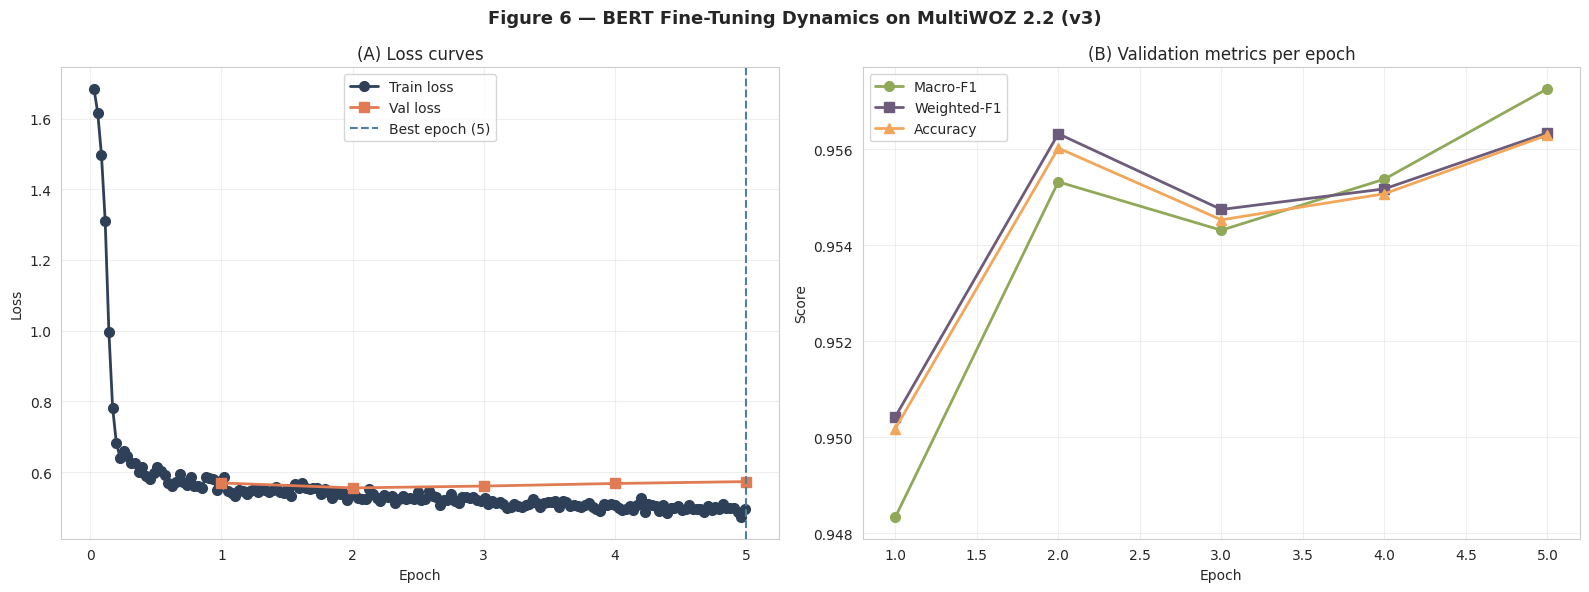

Figure 6 saved.


In [34]:
# ── Figure 6: Training Dynamics ───────────────────────────────────────────────
log_history = pd.DataFrame(trainer.state.log_history)
log_history.to_csv(TABLE_DIR / f'trainer_log_history_{MODEL_FAMILY}_{TARGET_COL}.csv', index=False)

train_log = log_history[log_history['loss'].notna()].copy()
eval_log  = log_history[log_history['eval_loss'].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Figure 6 — BERT Fine-Tuning Dynamics on MultiWOZ 2.2 (v3)',
             fontsize=13, fontweight='bold')

if not train_log.empty:
    axes[0].plot(train_log['epoch'], train_log['loss'], 'o-',
                 color='#2E4057', lw=2, ms=7, label='Train loss')
if not eval_log.empty:
    axes[0].plot(eval_log['epoch'], eval_log['eval_loss'], 's-',
                 color='#E07B54', lw=2, ms=7, label='Val loss')
    best_ep = eval_log.loc[eval_log['eval_f1_macro'].idxmax(), 'epoch'] if 'eval_f1_macro' in eval_log else None
    if best_ep:
        axes[0].axvline(best_ep, color='#4E8098', lw=1.5, ls='--',
                        label=f'Best epoch ({int(best_ep)})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('(A) Loss curves')
axes[0].legend()

if not eval_log.empty and 'eval_f1_macro' in eval_log.columns:
    axes[1].plot(eval_log['epoch'], eval_log['eval_f1_macro'],    'o-', color='#90A959', lw=2, ms=7, label='Macro-F1')
    axes[1].plot(eval_log['epoch'], eval_log['eval_f1_weighted'], 's-', color='#6C5B7B', lw=2, ms=7, label='Weighted-F1')
    axes[1].plot(eval_log['epoch'], eval_log['eval_accuracy'],    '^-', color='#F2A65A', lw=2, ms=7, label='Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_title('(B) Validation metrics per epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / f'fig6_training_dynamics_{MODEL_FAMILY}_{TARGET_COL}.png',
            dpi=200, bbox_inches='tight')
plt.show()
print('Figure 6 saved.')

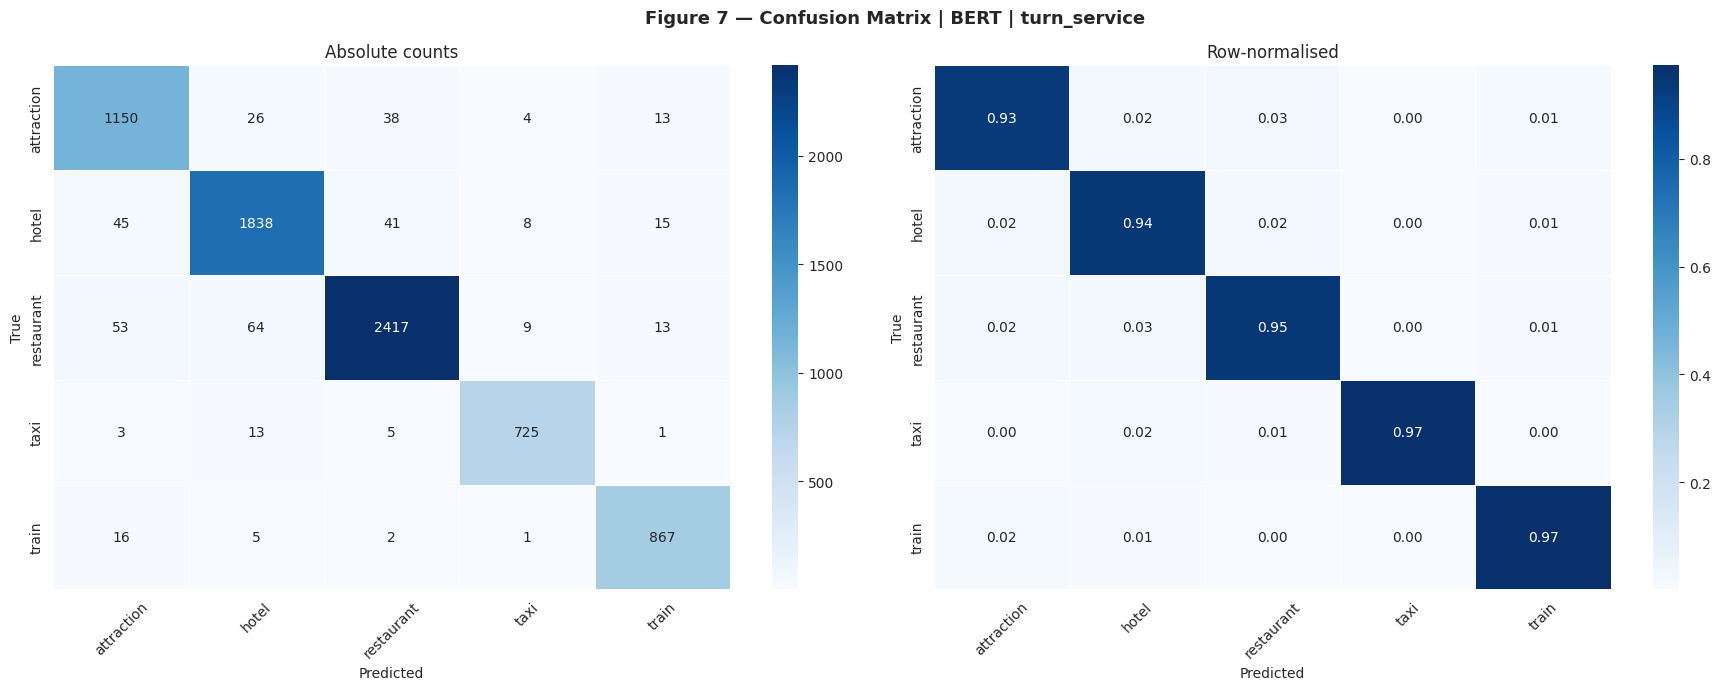

Figure 7 saved.


In [35]:
# ── Figure 7: Confusion Matrix ────────────────────────────────────────────────
cm = confusion_matrix(test_true_ids, test_pred_ids, labels=list(range(len(labels))))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(f'Figure 7 — Confusion Matrix | BERT | {TARGET_COL}',
             fontsize=13, fontweight='bold')

for ax, mat, title, fmt in [
    (axes[0], cm,      'Absolute counts', 'd'),
    (axes[1], cm_norm, 'Row-normalised',  '.2f')
]:
    sns.heatmap(mat, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                linewidths=0.5, linecolor='white', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(FIG_DIR / f'fig7_confusion_matrix_{MODEL_FAMILY}_{TARGET_COL}.png',
            dpi=200, bbox_inches='tight')
plt.show()
print('Figure 7 saved.')

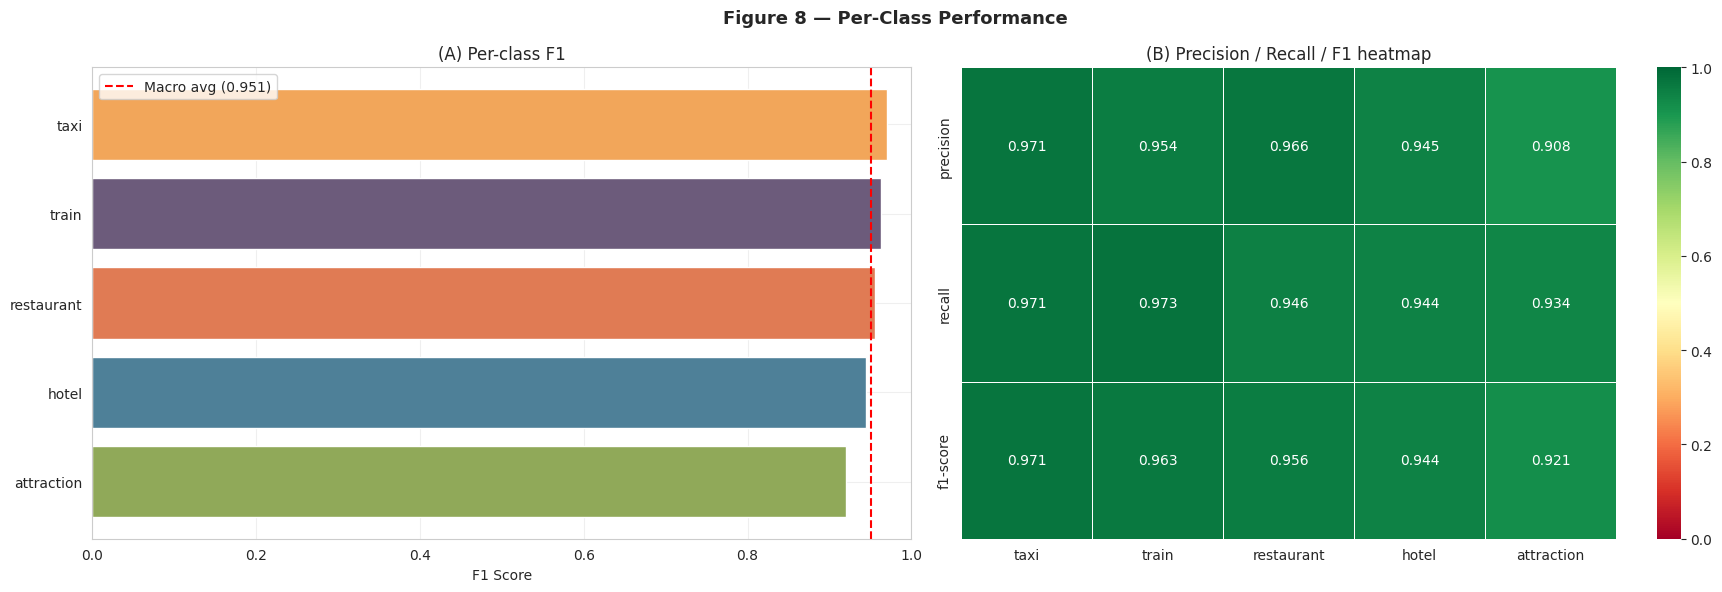

Figure 8 saved.


In [36]:
# ── Figure 8: Per-Class F1 and Multi-Metric Heatmap ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Figure 8 — Per-Class Performance', fontsize=13, fontweight='bold')

f1_vals = class_report_df['f1-score'].sort_values()
colors  = [PALETTE.get(l, '#888') for l in f1_vals.index]
axes[0].barh(f1_vals.index, f1_vals.values, color=colors)
axes[0].axvline(f1_macro, color='red', lw=1.5, ls='--', label=f'Macro avg ({f1_macro:.3f})')
axes[0].set_xlim(0, 1)
axes[0].set_xlabel('F1 Score')
axes[0].set_title('(A) Per-class F1')
axes[0].legend()

metrics_df = class_report_df[['precision', 'recall', 'f1-score']].copy()
sns.heatmap(metrics_df.T, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0, vmax=1, linewidths=0.5, ax=axes[1])
axes[1].set_title('(B) Precision / Recall / F1 heatmap')

plt.tight_layout()
plt.savefig(FIG_DIR / f'fig8_per_class_performance_{MODEL_FAMILY}_{TARGET_COL}.png',
            dpi=200, bbox_inches='tight')
plt.show()
print('Figure 8 saved.')

## 22. Error Analysis

In [37]:
errors_df = test_results_df[~test_results_df['is_correct']].copy()
errors_df['utt_len'] = errors_df['utterance'].str.split().map(len)

error_examples = errors_df[[
    'dialogue_id', 'turn_index', 'utterance',
    'true_label', 'pred_label', 'utt_len'
]].head(30)

error_examples.to_csv(TABLE_DIR / f'error_examples_{MODEL_FAMILY}_{TARGET_COL}.csv', index=False)

print('Most common confusion pairs:')
confusion_pairs = (
    errors_df.groupby(['true_label', 'pred_label'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
    .head(10)
)
print(confusion_pairs.to_string(index=False))
error_examples

Most common confusion pairs:
true_label pred_label  count
restaurant      hotel     64
restaurant attraction     53
     hotel attraction     45
     hotel restaurant     41
attraction restaurant     38
attraction      hotel     26
     train attraction     16
     hotel      train     15
      taxi      hotel     13
attraction      train     13


,dialogue_id,turn_index,utterance,true_label,pred_label,utt_len
0,MUL0484.json,0,i need train reservations from norwich to camb...,restaurant,hotel,8
6,PMUL4462.json,2,can you book me a table for 11:00 on friday?,restaurant,attraction,10
22,PMUL0320.json,14,"sounds great, thanks! actually, can you please...",hotel,attraction,14
78,PMUL0079.json,10,could you recommend an expensive restaurant in...,hotel,taxi,10
88,SNG0840.json,0,i need a five starts hotel close to a mall and...,restaurant,taxi,22
94,SNG0840.json,12,"yes, can you try it for 3 nights, please.",attraction,taxi,9
100,PMUL0089.json,6,find me a nice one and book for 5 people and 3...,restaurant,attraction,15
121,PMUL2009.json,14,"nope that's it, you have been oh so wonderful,...",restaurant,train,11
132,PMUL3858.json,4,no how about british food instead?,restaurant,attraction,6
137,PMUL3858.json,14,"that is all i need, thanks.",taxi,hotel,6


## 23. Summary

### All fixes applied (v1 + v2 + v3)

| Issue | Fix |
|---|---|
| Dialogue-level label noise | Turn-level `active_services` from `frames[*].service` |
| Bus / hospital destroying macro-F1 | `MIN_CLASS_COUNT = 500` drops both classes |
| System context injecting cross-domain noise | `model_input` uses prior USER turns only (v2) |
| `train` class massively over-predicted | Direct result of removing system `[SEP]` context (v2) |
| Underfitting | LR tuned to 2e-5; cosine scheduler; 10 epochs with early stopping (v3) |
| Weak context signal | `USER_CONTEXT_WINDOW = 4` (v3) |
| Input truncation | `MAX_LEN = 192` (v3) |
| No domain prefix signal | Intent prefix `[intent: <x>]` prepended to model_input (v3) |
| Overconfident predictions | Label smoothing ε=0.1 in WeightedTrainer (v3) |
| Class imbalance ignored | Balanced class weights via `WeightedTrainer` |
| No warmup | `warmup_ratio=0.1` + cosine LR decay |
| OOM during training | Gradient checkpointing + 8-bit AdamW + batch=16 + grad accum=2 (v3) |
| Zombie kernel eating VRAM | VRAM audit cell with nvidia-smi subprocess check (v3) |

In [39]:
"""

For Later Use:
=================


from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

SAVE_PATH = './working/models/bert_multiwoz_best'

tokenizer = AutoTokenizer.from_pretrained(SAVE_PATH)
model = AutoModelForSequenceClassification.from_pretrained(SAVE_PATH)
model.to('cuda')
model.eval()

# Quick test
text = "[intent: find_restaurant] i need a cheap restaurant in the centre"
inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=192).to('cuda')

with torch.no_grad():
    logits = model(**inputs).logits
    pred = logits.argmax(dim=-1).item()

print(f'Predicted: {model.config.id2label[pred]}')
"""

'\nfrom transformers import AutoTokenizer, AutoModelForSequenceClassification\nimport torch\n\nSAVE_PATH = \'./working/models/bert_multiwoz_best\'\n\ntokenizer = AutoTokenizer.from_pretrained(SAVE_PATH)\nmodel = AutoModelForSequenceClassification.from_pretrained(SAVE_PATH)\nmodel.to(\'cuda\')\nmodel.eval()\n\n# Quick test\ntext = "[intent: find_restaurant] i need a cheap restaurant in the centre"\ninputs = tokenizer(text, return_tensors=\'pt\', truncation=True, max_length=192).to(\'cuda\')\n\nwith torch.no_grad():\n    logits = model(**inputs).logits\n    pred = logits.argmax(dim=-1).item()\n\nprint(f\'Predicted: {model.config.id2label[pred]}\')\n'